In [2]:
import shutil
import os

input_folder = '/kaggle/input/dataset-tar-gz'  # replace with your dataset folder name
working_folder = '/kaggle/working/datasets'  # destination folder name in working dir

# Remove the destination folder if it already exists to avoid errors
if os.path.exists(working_folder):
    shutil.rmtree(working_folder)

# Copy the entire directory tree from input to working directory
shutil.copytree(input_folder, working_folder)

print(f"Copied {input_folder} to {working_folder}")

Copied /kaggle/input/dataset-tar-gz to /kaggle/working/datasets


In [1]:
## import shutil
import shutil
import os

src = '/kaggle/input/checkpoint4/best_model_resnet50.pth'
dst = '/kaggle/working/datasets/best_model_resnet50.pth'

shutil.copy(src, dst)

'/kaggle/working/datasets/best_model_resnet50.pth'

In [4]:
#checking clas
import os
for root, dirs, files in os.walk("/kaggle/working/datasets/split/"):
    print(root, "->", len(files), "files")

/kaggle/working/datasets/split/ -> 0 files
/kaggle/working/datasets/split/train -> 0 files
/kaggle/working/datasets/split/train/sashimi -> 750 files
/kaggle/working/datasets/split/train/bibimbap -> 750 files
/kaggle/working/datasets/split/train/cheese_plate -> 750 files
/kaggle/working/datasets/split/train/chicken_quesadilla -> 750 files
/kaggle/working/datasets/split/train/escargots -> 750 files
/kaggle/working/datasets/split/train/lasagna -> 750 files
/kaggle/working/datasets/split/train/oysters -> 750 files
/kaggle/working/datasets/split/train/french_fries -> 750 files
/kaggle/working/datasets/split/train/huevos_rancheros -> 750 files
/kaggle/working/datasets/split/train/deviled_eggs -> 750 files
/kaggle/working/datasets/split/train/eggs_benedict -> 750 files
/kaggle/working/datasets/split/train/hummus -> 750 files
/kaggle/working/datasets/split/train/donuts -> 750 files
/kaggle/working/datasets/split/train/ramen -> 750 files
/kaggle/working/datasets/split/train/club_sandwich -> 750

In [3]:
import os
import json
import shutil
from glob import glob
from tqdm import tqdm

# ---- PATHS ----
dataset_root = "/kaggle/working/datasets/food-101/images"   # folder containing class folders
train_json_path = "/kaggle/working/datasets/food-101/meta/train.json"
test_json_path  = "/kaggle/working/datasets/food-101/meta/test.json"

output_root = "/kaggle/working/datasets/split"
train_out = os.path.join(output_root, "train")
test_out  = os.path.join(output_root, "test")
os.makedirs(train_out, exist_ok=True)
os.makedirs(test_out, exist_ok=True)


# ---- LOAD JSON FILES ----
with open(train_json_path, "r") as f:
    train_dict = json.load(f)

with open(test_json_path, "r") as f:
    test_dict = json.load(f)


# ---- FUNCTION TO MOVE FILES ----
def move_split(json_dict, dst_root):
    for class_name, img_ids in json_dict.items():

        dst_class_folder = os.path.join(dst_root, class_name)
        os.makedirs(dst_class_folder, exist_ok=True)

        print(f"\nProcessing class: {class_name} ({len(img_ids)} images)")

        for img_id in tqdm(img_ids):

            # img_id example: "churros/1061830"
            class_folder, img_name = img_id.split("/")

            # find matching file (any extension)
            pattern = os.path.join(dataset_root, class_folder, img_name + ".*")
            matches = glob(pattern)

            if not matches:
                print(f"⚠️ Missing image for: {img_id}")
                continue

            src = matches[0]
            dst = os.path.join(dst_class_folder, os.path.basename(src))

            shutil.move(src, dst)   # MOVE instead of COPY


# ---- MOVE TRAIN FILES ----
print("Moving TRAIN split...")
move_split(train_dict, train_out)

# ---- MOVE TEST FILES ----
print("\nMoving TEST split...")
move_split(test_dict, test_out)

print("\n Dataset split completed using MOVE (No duplicate files).")

Moving TRAIN split...

Processing class: churros (750 images)


100%|██████████| 750/750 [00:00<00:00, 1107.31it/s]



Processing class: hot_and_sour_soup (750 images)


100%|██████████| 750/750 [00:00<00:00, 1133.83it/s]



Processing class: samosa (750 images)


...


Processing class: nachos (250 images)


100%|██████████| 250/250 [00:00<00:00, 3210.27it/s]



Processing class: oysters (250 images)


100%|██████████| 250/250 [00:00<00:00, 3191.99it/s]


✅ Dataset split completed using MOVE (No duplicate files).


In [5]:
import shutil

# Replace 'folder_to_download' with the directory in /kaggle/working
folder_path = '/kaggle/working/datasets/split'
zip_path = '/kaggle/working/datasets/split.zip'

shutil.make_archive(zip_path.replace('.zip', ''), 'zip', folder_path)

print(f"Directory compressed to {zip_path}")

Directory compressed to /kaggle/working/datasets/split.zip


In [1]:
import torch

if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0).lower()
    print(f"🔍 GPU detected: {gpu_name}")
    print(f"Using {torch.cuda.device_count()} GPUs")
    print(f"GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not available")

🔍 GPU detected: tesla t4
Using 2 GPUs
GPU is available: Tesla T4


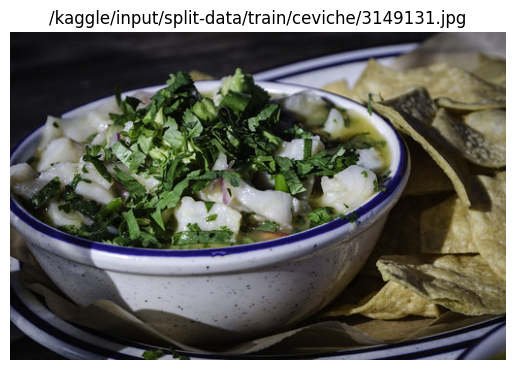

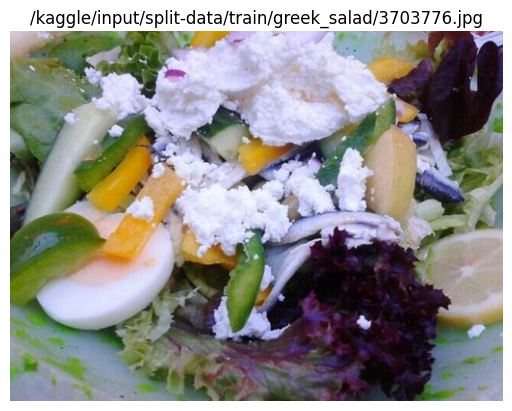

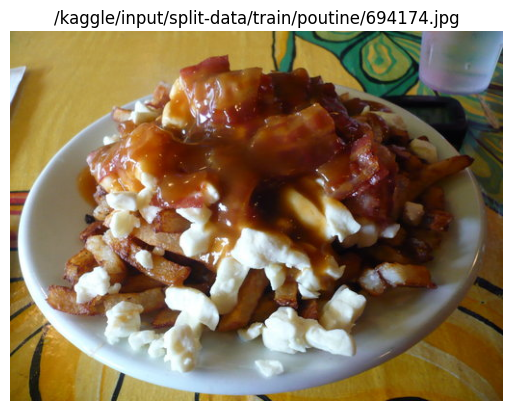

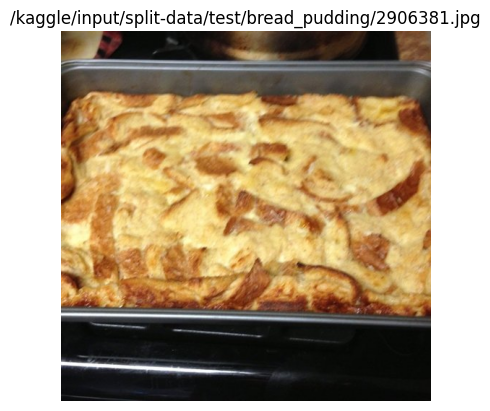

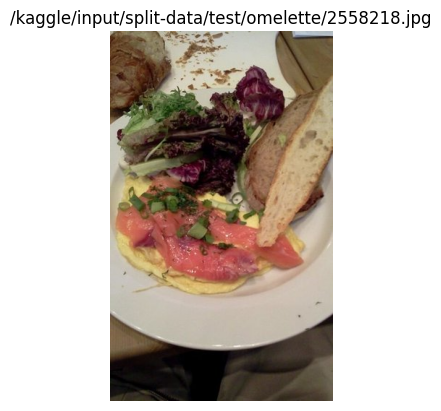

In [1]:
#random sample visualization
from PIL import Image
import matplotlib.pyplot as plt
import random
import glob

extract_path = "/kaggle/input/split-data/"
image_files = glob.glob(f"{extract_path}/**/*.jpg", recursive=True)
sample_images = random.sample(image_files, 5)

for img_path in sample_images:
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(img_path)
    plt.axis("off")
    plt.show()

In [ ]:
import torchvision
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.datasets import ImageFolder
from sklearn.metrics import f1_score, classification_report
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
import os



start_epoch = 0
start_batch = 0
best_f1 = 0   # track best Macro-F1
save_path = "/kaggle/working/datasets/best_model_resnet50.pth"
checkpoint_path = "/kaggle/working/datasets/resnet50_checkpoint.pth"


# ===============================
#  TRANSFORMS (384x384 high-res)
# ===============================

resnet50_highres_train = transforms.Compose([
    transforms.Resize(448),                 # maintain aspect ratio, shorter side = 448
    transforms.RandomResizedCrop(384),      # produce 384x384 crop
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2, 0.1),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225]),
])

resnet50_highres_val = transforms.Compose([
    transforms.Resize(448),
    transforms.CenterCrop(384),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225]),
])



# ===============================
#  DATASET + DATALOADER
# ===============================
train_dir = "/kaggle/input/split-data/train"
val_dir   = "/kaggle/input/split-data/test"

train_ds = ImageFolder(train_dir, transform=resnet50_highres_train)
val_ds   = ImageFolder(val_dir,   transform=resnet50_highres_val)

def detect_gpu_and_batch():
    """Return optimal batch size for Colab GPU."""
    if not torch.cuda.is_available():
        print("⚠️ Training on CPU → using safe batch_size = 4")
        return 4

    gpu_name = torch.cuda.get_device_name(0).lower()
    print(f"🔍 GPU detected: {gpu_name}")

    if "tesla t4" in gpu_name:
        return 64
    elif "v100" in gpu_name:
        return 32
    elif "t4" in gpu_name:
        return 16
    elif "p100" in gpu_name:
        return 16
    elif "k80" in gpu_name:
        return 8
    else:
        return 8  # default fallback

batch_size = detect_gpu_and_batch()

use_gpu = torch.cuda.is_available()
num_workers = 4 if use_gpu else 2
pin_memory = True if use_gpu else False

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=pin_memory)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=pin_memory)

num_classes = len(train_ds.classes)
print("Classes:", num_classes)

# ===============================
#  MODEL
# ===============================
device = "cuda" if torch.cuda.is_available() else "cpu"

model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(model.fc.in_features, num_classes)

if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
model = model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=10,  # epochs
    eta_min=1e-6
)

criterion = nn.CrossEntropyLoss()

if os.path.exists(checkpoint_path):
    print("🔄 Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device,weights_only=False)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    start_epoch = checkpoint["epoch"]
    start_batch = checkpoint["batch"]
    best_f1 = checkpoint["best_f1"]
    print(f"✔ Resumed from epoch {start_epoch}, batch {start_batch}, best Macro-F1 = {best_f1:.4f}")
else:
    print("⚠️ No checkpoint found — starting fresh.")


# ===============================
#  TRAINING + VALIDATION LOOP
# ===============================
for epoch in range(start_epoch,15):
    model.train()
    train_loss = 0

    for batch_idx, (imgs, labels) in enumerate(tqdm(train_loader, desc=f"Epoch {epoch+1}/15 - Training")):

        # skip already completed batches when resuming
        if epoch == start_epoch and batch_idx < start_batch:
            continue

        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()

        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        # ----- SAVE CHECKPOINT EVERY 100 BATCHES -----
        if (batch_idx + 1) % 100 == 0:
            torch.save({
                "epoch": epoch,
                "batch": batch_idx + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": scheduler.state_dict(),
                "best_f1": best_f1,
            }, checkpoint_path)
            print(f"💾 Checkpoint saved at epoch {epoch+1}, batch {batch_idx+1}")

    # reset start_batch after finishing resumed epoch
    start_batch = 0

    # ----- VALIDATION -----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for imgs, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/15 - Validation"):
            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total * 100
    macro_f1 = f1_score(all_labels, all_preds, average='macro')

    print(f"\nEpoch {epoch+1} Result → "
          f"Train Loss = {train_loss/len(train_loader):.4f} | "
          f"Val Loss = {val_loss/len(val_loader):.4f} | "
          f"Val Acc = {acc:.2f}% | Macro-F1 = {macro_f1:.4f}")

    print(classification_report(all_labels, all_preds, target_names=train_ds.classes))
    cm = confusion_matrix(all_labels, all_preds, normalize='true')
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, cmap="Blues")
    plt.title("Normalized Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # ----- SAVE BEST MODEL -----
    if macro_f1 > best_f1:
        best_f1 = macro_f1
        torch.save(model.state_dict(), save_path)
        print(f"🔥 Best model updated (Macro-F1 = {best_f1:.4f})")

    # ----- Save checkpoint at end of each epoch as well -----
    torch.save({
        "epoch": epoch + 1,
        "batch": 0,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_f1": best_f1,
    }, checkpoint_path)

    print("💾 End-of-epoch checkpoint saved.")
    scheduler.step()